In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from dotenv import load_dotenv
from pathlib import Path
from src.ingestion.loaders import load_file


In [2]:
transaction_dataframe = load_file()

In [3]:
transaction_dataframe.head(3)

,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_TYPE,TX_AMOUNT,TIMESTAMP,IS_FRAUD,ALERT_ID
0,1,6456,9069,TRANSFER,465.05,0,False,-1
1,2,7516,9543,TRANSFER,564.64,0,False,-1
2,3,2445,9356,TRANSFER,598.94,0,False,-1


In [4]:
transaction_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   TX_ID                1048575 non-null  int64  
 1   SENDER_ACCOUNT_ID    1048575 non-null  int64  
 2   RECEIVER_ACCOUNT_ID  1048575 non-null  int64  
 3   TX_TYPE              1048575 non-null  str    
 4   TX_AMOUNT            1048575 non-null  float64
 5   TIMESTAMP            1048575 non-null  int64  
 6   IS_FRAUD             1048575 non-null  bool   
 7   ALERT_ID             1048575 non-null  int64  
dtypes: bool(1), float64(1), int64(5), str(1)
memory usage: 57.0 MB


In [5]:
#check unique records for transaction id
transaction_dataframe["TX_ID"].nunique()

1048575

In [6]:
#check unique records for transaction type
transaction_dataframe["TX_TYPE"].nunique()

1

In [7]:
#delete id column
transaction_dataframe.drop(columns=["TX_ID"], inplace=True)

In [8]:
#delete leaky feature
transaction_dataframe.drop(columns=["ALERT_ID"], inplace=True)



In [9]:
#convert Is_Fraud to int
transaction_dataframe["IS_FRAUD"]=transaction_dataframe["IS_FRAUD"].astype(int)
transaction_dataframe["IS_FRAUD"].value_counts()

IS_FRAUD
0    1047246
1       1329
Name: count, dtype: int64

In [ ]:
transaction_dataframe["TIMESTAMP"].value_counts()

In [ ]:
#hour of day feature engineering
transaction_dataframe["HOUR_OF_DAY"] = transaction_dataframe["TIMESTAMP"] % 24
transaction_dataframe["HOUR_OF_DAY"].value_counts()

In [ ]:
#day feature engineering
transaction_dataframe["Day"] = transaction_dataframe["TIMESTAMP"] // 24
transaction_dataframe["Day"].value_counts()

In [14]:
transaction_dataframe["SENDER_STEP_COUNT"] = transaction_dataframe.groupby(["SENDER_ACCOUNT_ID", "TIMESTAMP"])["TX_AMOUNT"].transform("count")
transaction_dataframe["SENDER_STEP_COUNT"].head()

0    1
1    1
2    1
3    1
4    1
Name: SENDER_STEP_COUNT, dtype: int64

In [15]:
transaction_dataframe["SENDER_TOTAL_COUNT"] = transaction_dataframe.groupby("SENDER_ACCOUNT_ID")["TX_AMOUNT"].transform("count")
transaction_dataframe[["SENDER_ACCOUNT_ID", "SENDER_TOTAL_COUNT"]].head()

,SENDER_ACCOUNT_ID,SENDER_TOTAL_COUNT
0,6456,142
1,7516,143
2,2445,143
3,2576,143
4,3524,142


In [16]:
transaction_dataframe["SENDER_RECEIVER_PAIR_COUNT"] = transaction_dataframe.groupby(["SENDER_ACCOUNT_ID", "RECEIVER_ACCOUNT_ID"])["TX_AMOUNT"].transform("count")
transaction_dataframe[["SENDER_ACCOUNT_ID", "RECEIVER_ACCOUNT_ID", "SENDER_RECEIVER_PAIR_COUNT"]].head()


,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,SENDER_RECEIVER_PAIR_COUNT
0,6456,9069,142
1,7516,9543,143
2,2445,9356,143
3,2576,4617,143
4,3524,1773,142


In [ ]:
transaction_dataframe[transaction_dataframe["SENDER_ACCOUNT_ID"] == 7123]

<Axes: >

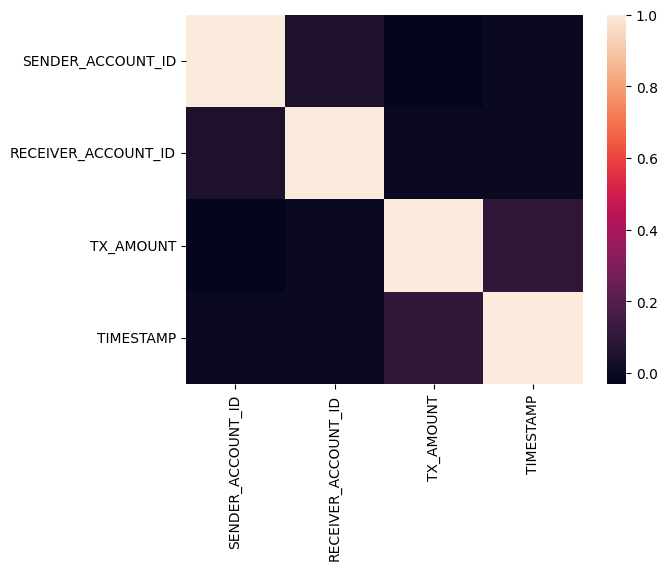

In [10]:
## Create correlation matrix
correlation = transaction_dataframe.select_dtypes("number").drop(columns=["IS_FRAUD"]).corr()
# Plot heatmap of 'correlation'
sns.heatmap(correlation)

In [ ]:
#drop highly correlated features
THRESHOLD = 0.8
TARGET = "IS_FRAUD"
EXCLUDE = ["TX_ID", "ALERT_ID"]  # identifier + leaky feature

# Build numeric frame; cast boolean target to int for correlation
num_cols = [
    c for c in transaction_dataframe.select_dtypes(include="number").columns
    if c not in EXCLUDE
]
corr_df = transaction_dataframe[num_cols].copy()
corr_df[TARGET] = transaction_dataframe[TARGET].astype(int)

corr_matrix = corr_df.corr()

# Absolute correlation of every feature with the target
target_corr = corr_matrix[TARGET].abs().drop(TARGET)

# Find all feature pairs whose mutual |correlation| meets the threshold
feature_cols = [c for c in corr_matrix.columns if c != TARGET]
pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        a, b = feature_cols[i], feature_cols[j]
        pair_corr = abs(corr_matrix.loc[a, b])
        if pair_corr >= THRESHOLD:
            corr_a = target_corr[a]
            corr_b = target_corr[b]
            drop = a if corr_a < corr_b else b
            keep = b if drop == a else a
            pairs.append({
                "Feature A": a,
                "Feature B": b,
                "Pair |Corr|": round(pair_corr, 4),
                f"|Corr({a}, {TARGET})|": round(corr_a, 4),
                f"|Corr({b}, {TARGET})|": round(corr_b, 4),
                "Drop": drop,
                "Keep": keep,
            })

if pairs:
    display(pd.DataFrame(pairs))
    cols_to_drop = list({r["Drop"] for r in pairs})
    transaction_dataframe.drop(columns=cols_to_drop, inplace=True)
    print(f"\nDropped : {cols_to_drop}")
    print(f"Remaining columns: {transaction_dataframe.columns.tolist()}")
else:
    print(f"No feature pairs with |correlation| >= {THRESHOLD}")

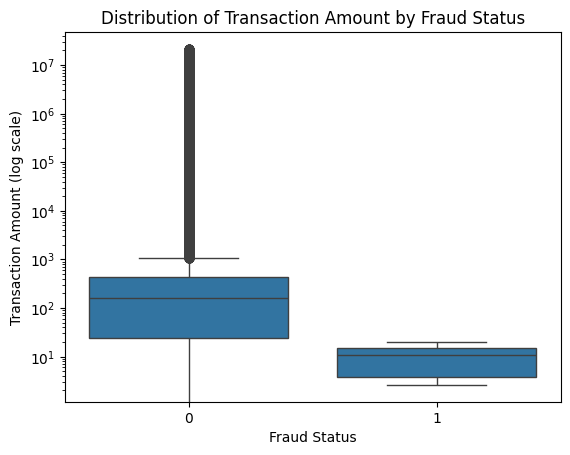

In [11]:
# Create boxplot for transaction amount by fraud status
#using log scale as Fraud staus is low:
sns.boxplot(x="IS_FRAUD", y="TX_AMOUNT", data=transaction_dataframe)
# Label axes
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount (log scale)")
plt.title("Distribution of Transaction Amount by Fraud Status")
plt.yscale("log")
plt.show()

In [ ]:
import numpy as np
from scipy.stats import chi2_contingency

SKEW_THRESHOLD = 1.0
EXCLUDE = {"TX_ID", "ALERT_ID", "IS_FRAUD"}
features = [
    c for c in transaction_dataframe.select_dtypes(include="number").columns
    if c not in EXCLUDE
]

overall_fraud_rate = transaction_dataframe["IS_FRAUD"].mean()

# ── 1. Outlier × Fraud cross-tab ──────────────────────────────────────────────
print("── Outlier × Fraud Cross-tab ───────────────────────────────────────────")
fraud_correlated = {}
xtab_rows = []

for feat in features:
    col = transaction_dataframe[feat]
    Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
    IQR = Q3 - Q1
    is_outlier = (col < Q1 - 1.5 * IQR) | (col > Q3 + 1.5 * IQR)
    n_outliers = int(is_outlier.sum())

    # Guard 1: no outliers at all
    if n_outliers == 0:
        fraud_correlated[feat] = False
        xtab_rows.append({
            "Feature": feat,
            "Fraud rate in outliers": "N/A",
            "Fraud rate in non-outliers": round(overall_fraud_rate, 4),
            "Overall fraud rate": round(overall_fraud_rate, 4),
            "Chi2 p-value": "N/A",
            "Fraud-correlated?": "NO outliers — safe to winsorize",
        })
        print(f"  {feat}: no outliers (IQR={IQR:.3f}) — skipping")
        continue

    # Guard 2: IQR=0 means every point is an "outlier" — test is meaningless
    if IQR == 0:
        fraud_correlated[feat] = False
        xtab_rows.append({
            "Feature": feat,
            "Fraud rate in outliers": "N/A",
            "Fraud rate in non-outliers": "N/A",
            "Overall fraud rate": round(overall_fraud_rate, 4),
            "Chi2 p-value": "N/A",
            "Fraud-correlated?": "IQR=0 — all values flagged as outliers, test skipped",
        })
        print(f"  {feat}: IQR=0 (constant-like column) — skipping chi2")
        continue

    ct = pd.crosstab(
        is_outlier.map({True: "Outlier", False: "Normal"}),
        transaction_dataframe["IS_FRAUD"].map({True: "Fraud", False: "Legit"})
    )

    # Guard 3: cross-tab must be 2×2 for chi2 to be valid
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        fraud_correlated[feat] = False
        xtab_rows.append({
            "Feature": feat,
            "Fraud rate in outliers": "N/A",
            "Fraud rate in non-outliers": "N/A",
            "Overall fraud rate": round(overall_fraud_rate, 4),
            "Chi2 p-value": "N/A",
            "Fraud-correlated?": f"Degenerate table {ct.shape} — test skipped",
        })
        print(f"  {feat}: cross-tab shape {ct.shape} — not enough categories for chi2")
        continue

    display(ct.rename_axis(feat))
    _, p, _, _ = chi2_contingency(ct)
    rate_out  = transaction_dataframe.loc[is_outlier,  "IS_FRAUD"].mean()
    rate_norm = transaction_dataframe.loc[~is_outlier, "IS_FRAUD"].mean()
    correlated = (p < 0.05) and (rate_out > overall_fraud_rate)
    fraud_correlated[feat] = correlated

    xtab_rows.append({
        "Feature": feat,
        "Fraud rate in outliers": round(rate_out, 4),
        "Fraud rate in non-outliers": round(rate_norm, 4),
        "Overall fraud rate": round(overall_fraud_rate, 4),
        "Chi2 p-value": f"{p:.2e}",
        "Fraud-correlated?": "YES → keep" if correlated else "NO → safe to winsorize",
    })

display(pd.DataFrame(xtab_rows).set_index("Feature"))

# ── 2. log1p on highly skewed features (new column — preserves originals) ─────
print("\n── Skewness Before / After log1p ───────────────────────────────────────")
skew_rows = []
for feat in features:
    before = transaction_dataframe[feat].skew()
    if abs(before) > SKEW_THRESHOLD:
        log_col = f"{feat}_log"
        transaction_dataframe[log_col] = np.log1p(transaction_dataframe[feat])
        after = transaction_dataframe[log_col].skew()
        action = f"→ created {log_col}"
    else:
        after = "—"
        action = "no transform needed"
    skew_rows.append({
        "Feature": feat,
        "Skew before": round(before, 3),
        "Skew after log1p": round(after, 3) if isinstance(after, float) else after,
        "Action": action,
    })

display(pd.DataFrame(skew_rows).set_index("Feature"))

# ── 3. Winsorize only non-fraud-correlated features (1st–99th percentile) ─────
print("\n── Winsorization ────────────────────────────────────────────────────────")
for feat in features:
    if fraud_correlated[feat]:
        print(f"  SKIP  {feat:30s} — outliers are fraud-correlated, preserving signal")
    else:
        col = transaction_dataframe[feat]
        lo, hi = col.quantile(0.01), col.quantile(0.99)
        transaction_dataframe[feat] = col.clip(lower=lo, upper=hi)
        print(f"  CLIP  {feat:30s} — capped to [{lo:.3f}, {hi:.3f}]")

In [ ]:
print(transaction_dataframe["IS_FRAUD"].value_counts(normalize=True).mul(100).round(2))


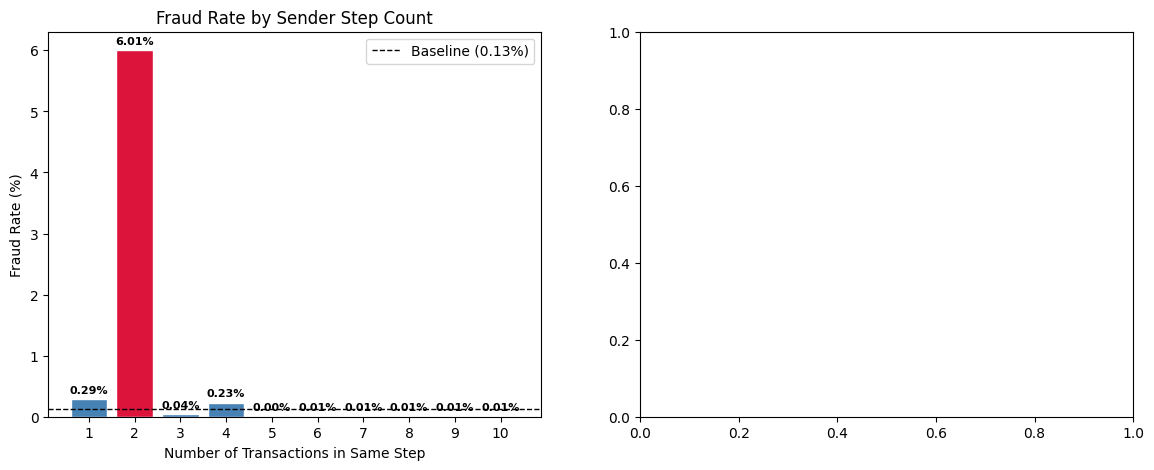

In [19]:
# --- SENDER_STEP_COUNT ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
step_fraud = (
    transaction_dataframe.groupby("SENDER_STEP_COUNT")["IS_FRAUD"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"IS_FRAUD": "fraud_rate"})
    .head(10)
)
colors_step = ["crimson" if v == step_fraud["fraud_rate"].max() else "steelblue"
               for v in step_fraud["fraud_rate"]]

axes[0].bar(step_fraud["SENDER_STEP_COUNT"].astype(str), step_fraud["fraud_rate"],
            color=colors_step, edgecolor="white")
axes[0].axhline(y=0.13, color="black", linestyle="--", linewidth=1, label="Baseline (0.13%)")
axes[0].set_title("Fraud Rate by Sender Step Count")
axes[0].set_xlabel("Number of Transactions in Same Step")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].legend()
for i, row in step_fraud.iterrows():
    axes[0].text(i, row["fraud_rate"] + 0.1, f"{row['fraud_rate']:.2f}%",
                 ha="center", fontsize=8, fontweight="bold")

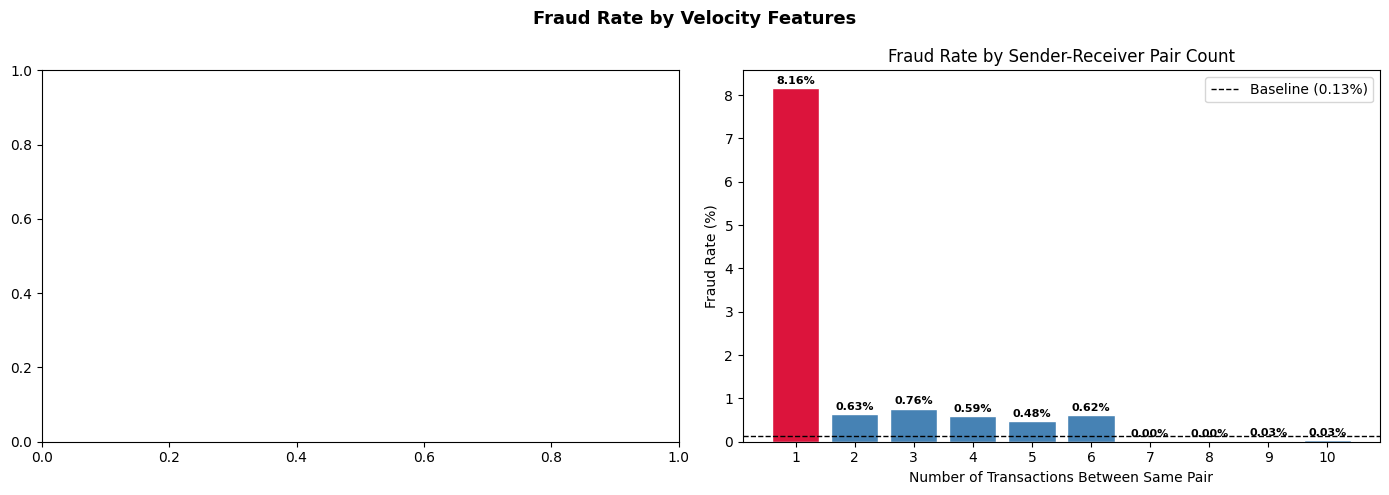

In [21]:
# --- SENDER_RECEIVER_PAIR_COUNT ---
# --- SENDER_STEP_COUNT ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pair_fraud = (
    transaction_dataframe.groupby("SENDER_RECEIVER_PAIR_COUNT")["IS_FRAUD"]
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={"IS_FRAUD": "fraud_rate"})
    .head(10)
)
colors_pair = ["crimson" if v == pair_fraud["fraud_rate"].max() else "steelblue"
               for v in pair_fraud["fraud_rate"]]

axes[1].bar(pair_fraud["SENDER_RECEIVER_PAIR_COUNT"].astype(str), pair_fraud["fraud_rate"],
            color=colors_pair, edgecolor="white")
axes[1].axhline(y=0.13, color="black", linestyle="--", linewidth=1, label="Baseline (0.13%)")
axes[1].set_title("Fraud Rate by Sender-Receiver Pair Count")
axes[1].set_xlabel("Number of Transactions Between Same Pair")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].legend()
for i, row in pair_fraud.iterrows():
    axes[1].text(i, row["fraud_rate"] + 0.1, f"{row['fraud_rate']:.2f}%",
                 ha="center", fontsize=8, fontweight="bold")

plt.suptitle("Fraud Rate by Velocity Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()